# Specific Stock Simulation


In [1]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [2]:
ticker = "SHEL.L"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "6mo"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [3]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [4]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [5]:
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,Daily_Return,Cumulative_Return,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_analysis_score,sentiment_analysis_score,multifactor_analysis_score,Signal,Signal_Text
0,2026-03-16,3378.0,3424.5,3372.500000,3415.0,3415.000000,10616421,SHEL.L,NaN,NaN,...,NaN,NaN,37.0,0.00,-0.10,0.8,0.0,0.285,0.33305,WEAK BUY
1,2026-03-13,3331.0,3378.0,3331.000000,3367.5,3367.500000,8283922,SHEL.L,NaN,NaN,...,-0.013909,-0.013909,36.5,0.10,-0.45,0.8,0.0,0.285,0.25055,WEAK BUY
2,2026-03-12,3250.0,3329.0,3235.000000,3328.0,3328.000000,12881194,SHEL.L,NaN,NaN,...,-0.011730,-0.025476,78.0,0.10,-0.45,0.8,0.0,0.285,0.25055,WEAK BUY
3,2026-03-11,3166.5,3244.0,3158.000000,3244.0,3244.000000,11666644,SHEL.L,NaN,NaN,...,-0.025240,-0.050073,77.5,0.10,-0.45,0.8,0.0,0.285,0.25055,WEAK BUY
4,2026-03-10,3142.0,3198.5,3107.500000,3180.5,3180.500000,13067969,SHEL.L,NaN,NaN,...,-0.019575,-0.068668,38.5,0.10,-0.45,0.8,0.0,0.285,0.25055,WEAK BUY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,2025-09-22,2618.5,2627.0,2603.500000,2614.5,2613.926514,8288254,SHEL.L,2676.10,2697.775,...,-0.011531,-0.234407,-4.0,0.15,-0.60,0.8,0.0,0.285,0.21755,WEAK BUY
123,2025-09-19,2632.0,2640.0,2608.428955,2612.5,2611.927002,22421970,SHEL.L,2667.10,2693.850,...,-0.000765,-0.234993,-19.5,0.40,-0.55,0.8,0.0,0.285,0.31655,WEAK BUY
124,2025-09-18,2607.5,2637.5,2605.538086,2622.5,2621.924805,9887601,SHEL.L,2662.30,2691.150,...,0.003828,-0.232064,15.0,0.25,-0.60,0.8,0.0,0.285,0.25055,WEAK BUY
125,2025-09-17,2646.5,2650.0,2598.500000,2606.0,2605.428223,7243439,SHEL.L,2654.85,2686.875,...,-0.006292,-0.236896,-40.5,0.45,-0.60,0.8,0.0,0.285,0.31655,WEAK BUY


In [6]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2025-09-16,BUY,WEAK BUY,2635.25,0.001897,5.0,95.0,0.001897,100.003320
1,2025-09-17,BUY,WEAK BUY,2626.25,0.001904,5.0,90.0,0.003801,99.905949
2,2025-09-18,BUY,WEAK BUY,2615.00,0.001912,5.0,85.0,0.005713,99.983010
3,2025-09-19,BUY,WEAK BUY,2622.25,0.001907,5.0,80.0,0.007620,99.907286
4,2025-09-22,BUY,WEAK BUY,2616.50,0.001911,5.0,75.0,0.009531,99.918704
5,2025-09-23,BUY,WEAK BUY,2635.00,0.001898,5.0,70.0,0.011428,100.228374
6,2025-09-24,BUY,WEAK BUY,2654.25,0.001884,5.0,65.0,0.013312,100.583693
7,2025-09-25,BUY,WEAK BUY,2684.50,0.001863,5.0,60.0,0.015175,100.956819
8,2025-09-26,BUY,WEAK BUY,2725.50,0.001835,5.0,55.0,0.017009,101.495026
9,2025-09-29,BUY,WEAK BUY,2709.50,0.001845,5.0,50.0,0.018855,100.832263


In [7]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2025-09-16,2026-03-16,100.0,0.0,0.03726,2683.840832,3415.0,127.243015,127.243015,27.243015,27.243015,20,0


## Block 6: Consolidated Chart


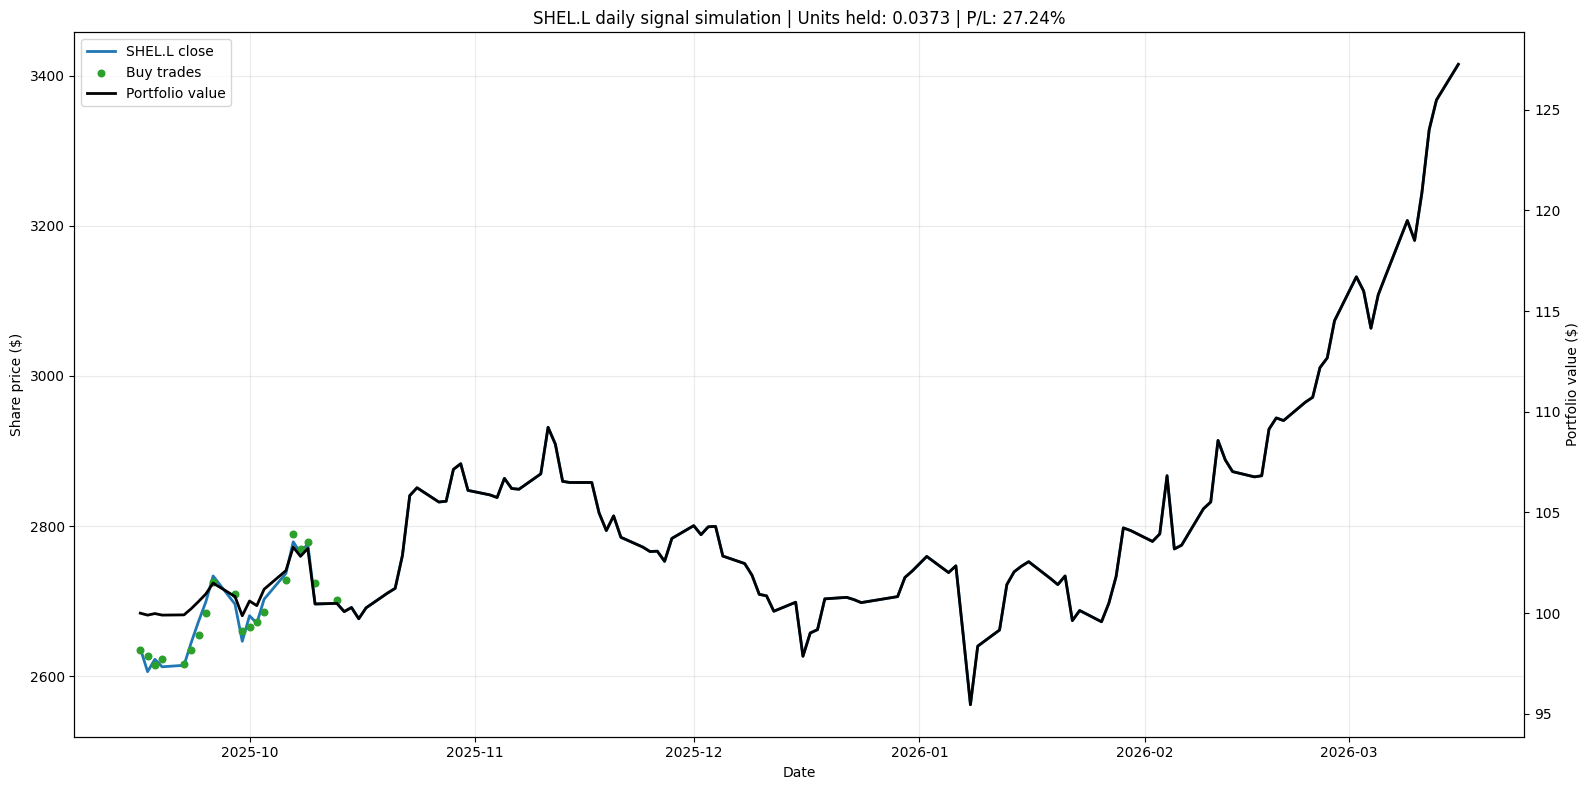

In [8]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [9]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2025-09-16,WEAK BUY,BUY,0.001897,5.0,95.0,0.001897,5.003320,100.003320,0.003320
1,2025-09-17,WEAK BUY,BUY,0.001904,5.0,90.0,0.003801,9.905949,99.905949,-0.094051
2,2025-09-18,WEAK BUY,BUY,0.001912,5.0,85.0,0.005713,14.983010,99.983010,-0.016990
3,2025-09-19,WEAK BUY,BUY,0.001907,5.0,80.0,0.007620,19.907286,99.907286,-0.092714
4,2025-09-22,WEAK BUY,BUY,0.001911,5.0,75.0,0.009531,24.918704,99.918704,-0.081296
...,...,...,...,...,...,...,...,...,...,...
122,2026-03-10,WEAK BUY,HOLD,0.000000,0.0,0.0,0.037260,118.505537,118.505537,18.505537
123,2026-03-11,WEAK BUY,HOLD,0.000000,0.0,0.0,0.037260,120.871550,120.871550,20.871550
124,2026-03-12,WEAK BUY,HOLD,0.000000,0.0,0.0,0.037260,124.001392,124.001392,24.001392
125,2026-03-13,WEAK BUY,HOLD,0.000000,0.0,0.0,0.037260,125.473164,125.473164,25.473164
